# Reliability Analysis of CNC01's failures

This notebook aims to caracterize the failure behaviour of the machine by calculating it's key reliability indicators focusing on tool wear failures, providing useful information for the PdM program implementation.

## Preparing the data


In [1]:
# Imports
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from local_settings import postgres_url as url
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Load 'milling_pdm_celsius' dataset to a pandas dataframe and show
url = f"postgresql+psycopg2://{url['pguser']}:{url['pgpassword']}@{url['pghost']}/{url['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


In [3]:
# Load 'failure_data_unpivoted' dataset to a pandas dataframe and show
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL


In [4]:
# Create dataframe indicating tool replacements
df["tool_replaced"] = df["tool_wear_min"] == 0
df.loc[1, "tool_replaced"] = False # first tool is not considered a replacement
df["tool_replaced"]

register_id
1        False
2        False
3        False
4        False
5        False
         ...  
9996     False
9997     False
9998     False
9999     False
10000    False
Name: tool_replaced, Length: 10000, dtype: bool

## Failure overview

This section presents an overview of the failure data for CNC01, reviewing key findings of the statistical profiling and process variables analysis.

In [5]:
# Ratio of data points that a failure was reported
num_of_failures = df[df["tool_wear_failure"] + df["heat_dissipation_failure"] + df["power_failure"] + df["overstrain_failure"] + df["random_failure"]].shape[0]
print(f"Number of total failures = {num_of_failures}")
print(f"Ratio of failures in the dataset for all modes = {num_of_failures / df.shape[0]*100:.2f} %")

Number of total failures = 348
Ratio of failures in the dataset for all modes = 3.48 %


In [6]:
# Ratio of data points that a failure was reported
num_of_twf_failures = df[df["tool_wear_failure"]].shape[0]
print(f"Number of TWF failures = {num_of_twf_failures}")
print(f"Ratio of TWF failures in the dataset = {num_of_twf_failures / df.shape[0]*100:.2f} %")

Number of TWF failures = 46
Ratio of TWF failures in the dataset = 0.46 %


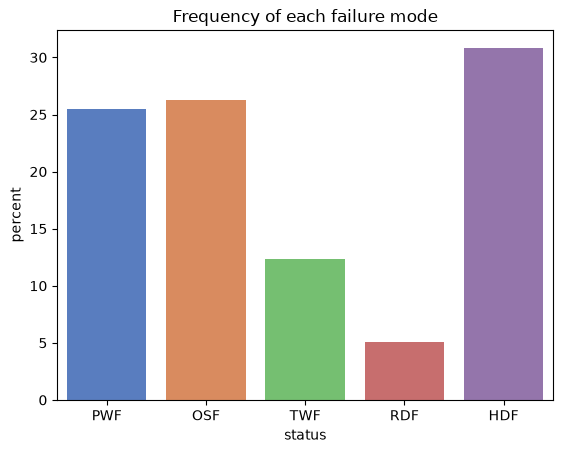

In [7]:
# Review of distribution of failure modes
sns.countplot(data=df_failure_mode[df_failure_mode["status"]!="NORMAL"], x='status', hue='status', palette='muted', stat='percent', legend=False)
plt.title('Frequency of each failure mode')
plt.show()

- Only 348 failures were detected in the 10k cycles registered in the database

- Most of the reported failures were due to HDF corresponding to approximately 30% of the failures

- Tool breaks due to wear occured at 46 data points, being the second most rare failure mode

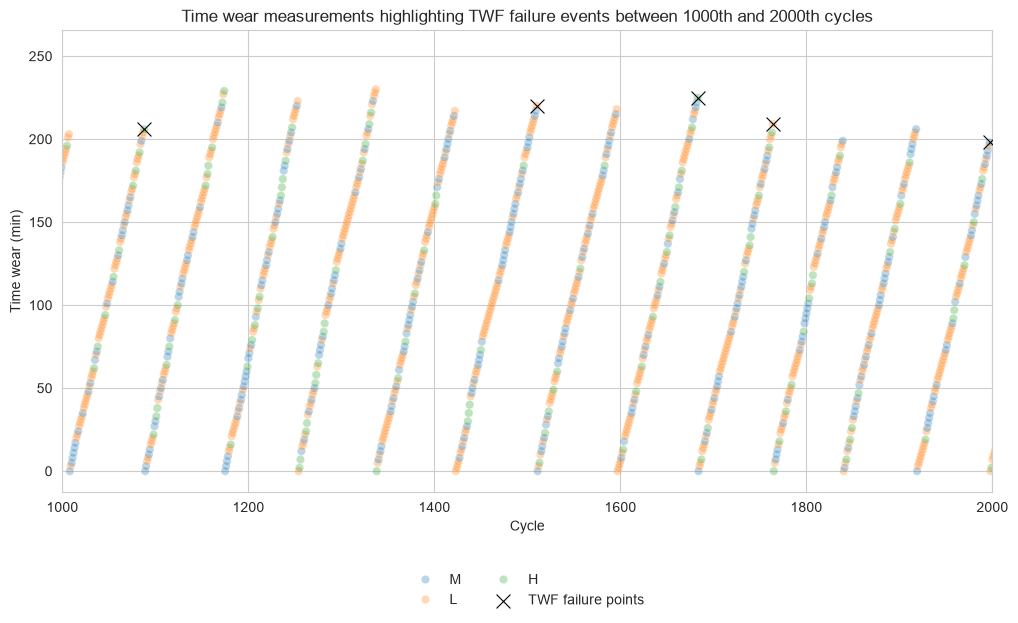

In [8]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                hue="product_type",
                alpha=0.3)

## Plot failures
sns.scatterplot(data=df_twf,
                marker="x",
                s=100,
                color="#000000",
                zorder=5,
                label="TWF failure points")

## Plot settings
plt.xlim(left=1000, right=2000)
#plt.xticks(np.arange(0,10001,500))
plt.title("Time wear measurements highlighting TWF failure events between 1000th and 2000th cycles")
plt.xlabel("Cycle")
plt.ylabel("Time wear (min)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- By observing a slice of the tool wear measurements graph throughout the production cycles, it can be noted that a preventive maintenance strategy was already being applied in the operational window analyzed with tool replacements being done before TWF reports.

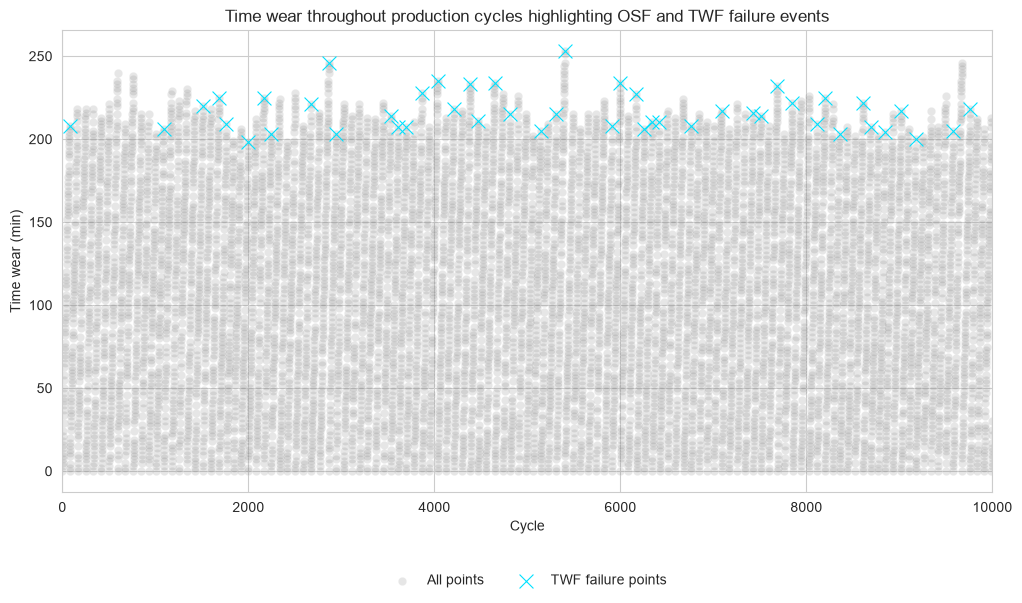

In [9]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                alpha=0.2,
                color="#858585",
                label="All points")

## Plot failures
sns.scatterplot(data=df_twf,
                marker="x",
                s=100,
                color="#00E1FF",
                zorder=5,
                label="TWF failure points")

## Plot settings
plt.xlim(left=0, right=10000)
#plt.xticks(np.arange(0,10001,500))
plt.title("Time wear throughout production cycles highlighting OSF and TWF failure events")
plt.xlabel("Cycle")
plt.ylabel("Time wear (min)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- Tool Wear Failures (TWF) are predominantly observed between 198 and 253 wear minutes of operation. This cluster indicates that the useful life of the tool is effectively bounded within this range, serving as a critical indicator for planned replacement strategies.

In [16]:
# How many tool replacements and how many of them were motivated by TWF?
num_of_replacements = df["tool_replaced"].sum()
num_of_twf = df["tool_wear_failure"].sum()
num_of_twf_and_replacements = (df["tool_replaced"].shift(-1) & df["tool_wear_failure"]).sum()
print(f"Number of tool replacements: {num_of_replacements:.0f}")
print(f"Number of tool wear failures: {num_of_twf:.0f}")
print(f"Number of TWF and replacements: {num_of_twf_and_replacements:.0f}")

Number of tool replacements: 119
Number of tool wear failures: 46
Number of TWF and replacements: 46


In [18]:
# Does the accumulated Tool Wear consistently return to near-zero values after replacement?
df["tool_wear_min"][df["tool_replaced"]].value_counts()

tool_wear_min
0    119
Name: count, dtype: int64

- TWF events are concentrated at high wear values, so there is no evidence that heavily worn tools are reintroduced into production and later fail with artificially low accumulated wear.

- Consistent resets to near-zero values suggest that a new tool is introduced after replacement, supporting the assumption of independent tool life cycles.

- If reused tools were present in significant numbers, one possible consequence would be the occurrence of TWF events at unexpectedly low accumulated Tool Wear values. The absence of such events provides supporting — though not conclusive — evidence for the single-use assumption.

## Failure rate by mode

The failure rate ($\lambda$) is defined as the number of failures per operating time:

$ \lambda = \dfrac{\textrm{NoF}}{\textrm{Operating time (cycles)}} $

As each row of the dataset represents one milling cycle, the frequency of each failure is the same as the failure rate per failure mode:

In [41]:
# Failure rate by failure mode
df_reliability_metrics = df_failure_mode["status"].value_counts(normalize=True, dropna=False) * 100
df_reliability_metrics = df_reliability_metrics.to_frame().reset_index().rename(columns={"status":"failure_mode", "proportion":"failure_rate"})
df_reliability_metrics = df_reliability_metrics[df_reliability_metrics["failure_mode"]!="NORMAL"]
df_reliability_metrics

,failure_mode,failure_rate
1,HDF,1.148163
2,OSF,0.978435
3,PWF,0.948482
4,TWF,0.459265
5,RDF,0.189696


In [47]:
# Global failure rate
num_of_machine_failures = df["machine_failure"].sum()
num_of_total_cycles = df.shape[0]
print(f"Number of machine failures = {num_of_machine_failures:.0f}")
print(f"Number of total cycles = {num_of_total_cycles:.0f}")
print(f"Global failure rate = {num_of_machine_failures / num_of_total_cycles*100:.2f}%")

Number of machine failures = 339
Number of total cycles = 10000
Global failure rate = 3.39%


## Mean time between failures (MTBF)

As each row of the dataset represents one milling cycle, the frequency of each failure

Como o dataset possui o tempo acumulado de desgaste (Tool Wear), você pode estimar um MTBF em minutos de operação.

Mostrar:

MTBF global

e talvez

MTBF por tipo de falha

Depois interpretar.

In [42]:
df_reliability_metrics["MTBF"] = 100 / df_reliability_metrics["failure_rate"]
df_reliability_metrics

,failure_mode,failure_rate,MTBF
1,HDF,1.148163,87.095652
2,OSF,0.978435,102.204082
3,PWF,0.948482,105.431579
4,TWF,0.459265,217.739130
5,RDF,0.189696,527.157895


## Weibull distribution

Não faria estimação complicada.

Eu faria algo como:

ajustar Weibull usando scipy

mostrar

β (shape)
η (scale)

Depois interpretar.

Se

β<1

→ falhas infantis

β≈1

→ aleatórias

β>1

→ desgaste

Essa interpretação é extremamente conhecida na engenharia.

## Reliability function R(t)

Mostrar

R(t)

probabilidade da máquina continuar operando sem falhar.

Depois responder perguntas como:

Após 100 minutos de desgaste, qual a probabilidade de ainda não ocorrer falha?

## Hazard rate H(t)

Taxa de falha (Hazard)

Se a Weibull foi ajustada:

mostrar

h(t)

Depois interpretar.

Exemplo:

"A taxa de falha cresce rapidamente após aproximadamente X minutos."

## Conclusion

Não falar apenas de estatística.

Falar como engenheiro.

Algo como:

existe evidência de desgaste progressivo?
manutenção preventiva faz sentido?
sensores parecem suficientes?
qual deve ser o próximo passo?